In [28]:
import os
import pandas as pd
import autoslo.utils.paths as pu

pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_ids = pu.RunLocator.get_run_ids(
                workload_name="{}pctheavy_{}meaninterarrival".format(
                    pct_heavy, mean_interarrival
                ),
                blueprint_name=f"single_{rpu}",
            )

            records.append(
                {
                    "pct_heavy": pct_heavy,
                    "mean_interarrival": mean_interarrival,
                    "rpu": rpu,
                    "blueprint_name": f"single_{rpu}",
                    "last_run_id": max(run_ids) if len(run_ids) > 0 else None,
                }
            )
results_df = pd.DataFrame(records)
results_df

,pct_heavy,mean_interarrival,rpu,blueprint_name,last_run_id
0,0,10,4,single_4,1763346358
1,0,10,8,single_8,1763315325
2,0,10,16,single_16,1763304261
3,0,10,32,single_32,1763978737
4,0,30,4,single_4,1763336464
...,...,...,...,...,...
59,50,60,32,single_32,1763970399
60,50,120,4,single_4,1763323616
61,50,120,8,single_8,1763299918
62,50,120,16,single_16,1763291740


In [29]:
# /home/markakis/chunkbench/data/runs/1763270759/
# features_FExtended(label_summary_metric=p95,label_in_log_space=True),use_num_queries=False),use_interarrival_time=True).pkl

from autoslo.workload_execution.trace import Trace
from autoslo.featurization.f_extended import FExtended

featurizer = FExtended(
    label_summary_metric="p95",
    label_in_log_space=True,
    use_num_queries=False,
    use_interarrival_time=True,
)

feature_names = featurizer.feature_names
label_name = featurizer.label_name

results_df[feature_names + [label_name]] = None

for row_idx, row in results_df.iterrows():
    if row["last_run_id"] is not None:
        trace = Trace(row["last_run_id"])
        featurization, label = featurizer.featurize_trace(trace, force=True)

        for feature_idx, feature_name in enumerate(feature_names):
            results_df.at[row_idx, feature_name] = featurization[feature_idx]
        results_df.at[row_idx, label_name] = label

# Make sure they are floats
for column in feature_names + [label_name]:
    results_df[column] = results_df[column].astype(float)





In [30]:
results_df.describe()

,pct_heavy,mean_interarrival,rpu,interarrival_time_s_mean,interarrival_time_s_p5,interarrival_time_s_p1,was_aborted_mean,was_cached_mean,num_permanent_tables_accessed_mean,num_external_tables_accessed_mean,num_system_tables_accessed_mean,mbytes_scanned_mean,mbytes_scanned_p95,mbytes_scanned_p99,num_joins_mean,num_joins_p95,num_joins_p99,num_scans_mean,num_scans_p95,num_scans_p99,num_aggregations_mean,num_aggregations_p95,num_aggregations_p99,query_type_analyze_mean,query_type_copy_mean,query_type_ctas_mean,query_type_delete_mean,query_type_insert_mean,query_type_other_mean,query_type_select_mean,query_type_unload_mean,query_type_update_mean,query_type_vacuum_mean,log1p_latency_s_p95
count,64.00000,64.000000,64.00000,64.000000,64.000000,64.000000,64.000000,64.0,64.000000,64.0,64.0,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.000000
mean,21.25000,55.000000,15.00000,60.729607,18.226287,11.654292,0.030127,0.0,8.908919,0.0,0.0,43612.536561,155457.785840,232148.595078,7.458639,16.871875,25.816875,12.964925,34.476562,39.220312,3.086213,10.518750,14.715313,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.821925
std,18.98203,41.861449,10.80858,42.238934,21.677813,19.049456,0.079030,0.0,1.168976,0.0,0.0,22957.406967,52934.751379,62669.957264,1.025623,2.992051,8.862477,2.025453,7.477373,5.923633,0.593532,3.963299,3.988266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.835476
min,0.00000,10.000000,4.00000,9.755240,0.204750,0.031909,0.000000,0.0,7.114286,0.0,0.0,9234.842289,61551.534657,63352.927709,5.685714,11.300000,12.000000,9.514286,24.000000,24.000000,2.200000,6.600000,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.327229
25%,7.50000,25.000000,7.00000,30.034324,2.453944,0.373253,0.000000,0.0,8.029412,0.0,0.0,23143.279247,103023.025567,194685.010824,6.666547,16.400000,18.520000,11.463164,25.500000,39.435000,2.527351,8.000000,11.565000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.887482
50%,17.50000,45.000000,12.00000,52.869696,9.622534,2.053624,0.000000,0.0,8.560000,0.0,0.0,38120.607455,166641.460589,250102.716425,7.280000,17.000000,24.310000,13.375580,36.450000,42.000000,3.137709,8.000000,17.190000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.809749
75%,31.25000,75.000000,20.00000,81.474079,25.760390,16.740701,0.000000,0.0,9.936508,0.0,0.0,65582.298310,197810.226101,289778.783883,8.412698,19.000000,36.000000,14.206349,42.000000,42.470000,3.557895,14.500000,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.689525
max,50.00000,120.000000,32.00000,147.071753,71.363814,66.540112,0.280702,0.0,10.851852,0.0,0.0,76848.468575,222724.559410,298612.983709,9.074074,21.700000,36.000000,16.148148,42.350000,43.000000,4.092593,18.000000,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.188970


In [ ]:
trace.num_()

query_id
0#cluster_32_8735172     NaN
1#cluster_32_8735269     NaN
2#cluster_32_8735418     NaN
3#cluster_32_8735601     NaN
4#cluster_32_8735731     NaN
5#cluster_32_8735880     NaN
6#cluster_32_8736057     NaN
7#cluster_32_8736208     0.0
8#cluster_32_8736301     NaN
9#cluster_32_8736352     NaN
10#cluster_32_8736489    NaN
11#cluster_32_8736594    NaN
12#cluster_32_8736700    NaN
13#cluster_32_8736781    NaN
14#cluster_32_8736872    NaN
15#cluster_32_8736935    NaN
16#cluster_32_8737072    NaN
17#cluster_32_8737152    NaN
18#cluster_32_8737287    NaN
19#cluster_32_8737349    NaN
20#cluster_32_8737477    NaN
21#cluster_32_8737526    NaN
22#cluster_32_8737611    NaN
23#cluster_32_8737754    NaN
24#cluster_32_8737905    NaN
Name: plan_node, dtype: float64

In [15]:
results_df

,pct_heavy,mean_interarrival,rpu,blueprint_name,last_run_id,interarrival_time_s_mean,interarrival_time_s_p5,interarrival_time_s_p1,was_aborted_mean,was_cached_mean,...,query_type_copy_mean,query_type_ctas_mean,query_type_delete_mean,query_type_insert_mean,query_type_other_mean,query_type_select_mean,query_type_unload_mean,query_type_update_mean,query_type_vacuum_mean,log1p_latency_s_p95
0,0,10,4.0,single_4,1763346358,62.967313,2.063975,0.295344,0.277612,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.188969
1,0,10,8.0,single_8,1763315325,30.809754,0.216225,0.109856,0.050746,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.18214
2,0,10,16.0,single_16,1763304261,17.052215,0.30084,0.031909,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.534724
3,0,10,32.0,single_32,1763978737,10.704214,2.583934,0.373253,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.066408
4,0,30,4.0,single_4,1763336464,57.608741,4.629732,1.961578,0.280702,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.18897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,50,60,32.0,single_32,1763970399,66.57454,25.732513,17.109772,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.395393
60,50,120,4.0,single_4,1763323616,147.071753,71.363814,66.540112,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.861897
61,50,120,8.0,single_8,1763299918,138.435412,66.38518,16.564375,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.498848
62,50,120,16.0,single_16,1763291740,146.534658,71.138281,66.45622,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.118501


In [23]:
pd.set_option('display.max_columns', None)

results_df.describe()

,pct_heavy,mean_interarrival,rpu,interarrival_time_s_mean,interarrival_time_s_p5,interarrival_time_s_p1,was_aborted_mean,was_cached_mean,num_permanent_tables_accessed_mean,num_external_tables_accessed_mean,num_system_tables_accessed_mean,mbytes_scanned_mean,mbytes_scanned_p95,mbytes_scanned_p99,num_joins_mean,num_joins_p95,num_joins_p99,num_scans_mean,num_scans_p95,num_scans_p99,num_aggregations_mean,num_aggregations_p95,num_aggregations_p99,query_type_analyze_mean,query_type_copy_mean,query_type_ctas_mean,query_type_delete_mean,query_type_insert_mean,query_type_other_mean,query_type_select_mean,query_type_unload_mean,query_type_update_mean,query_type_vacuum_mean,log1p_latency_s_p95
count,64.00000,64.000000,64.00000,64.000000,64.000000,64.000000,64.000000,64.0,64.000000,64.0,64.0,29.000000,29.000000,29.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.0,64.000000
mean,21.25000,55.000000,15.00000,60.729607,18.226287,11.654292,0.030127,0.0,0.003844,0.0,0.0,1313.150011,1836.317611,1903.296146,0.173469,0.219388,0.223469,0.088435,0.118367,0.121633,0.214286,0.223469,0.224286,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.821925
std,18.98203,41.861449,10.80858,42.238934,21.677813,19.049456,0.079030,0.0,0.009201,0.0,0.0,2515.365919,3843.657123,4050.272952,0.346876,0.412161,0.419660,0.259322,0.320432,0.329003,0.408248,0.419710,0.421189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.835476
min,0.00000,10.000000,4.00000,9.755240,0.204750,0.031909,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.327229
25%,7.50000,25.000000,7.00000,30.034324,2.453944,0.373253,0.000000,0.0,0.000000,0.0,0.0,0.042014,0.042014,0.042014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.887482
50%,17.50000,45.000000,12.00000,52.869696,9.622534,2.053624,0.000000,0.0,0.000000,0.0,0.0,104.400000,183.240000,190.248000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.809749
75%,31.25000,75.000000,20.00000,81.474079,25.760390,16.740701,0.000000,0.0,0.000000,0.0,0.0,853.561184,853.561184,853.561184,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.689525
max,50.00000,120.000000,32.00000,147.071753,71.363814,66.540112,0.280702,0.0,0.040000,0.0,0.0,8738.713776,13190.401578,14158.086332,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.188970


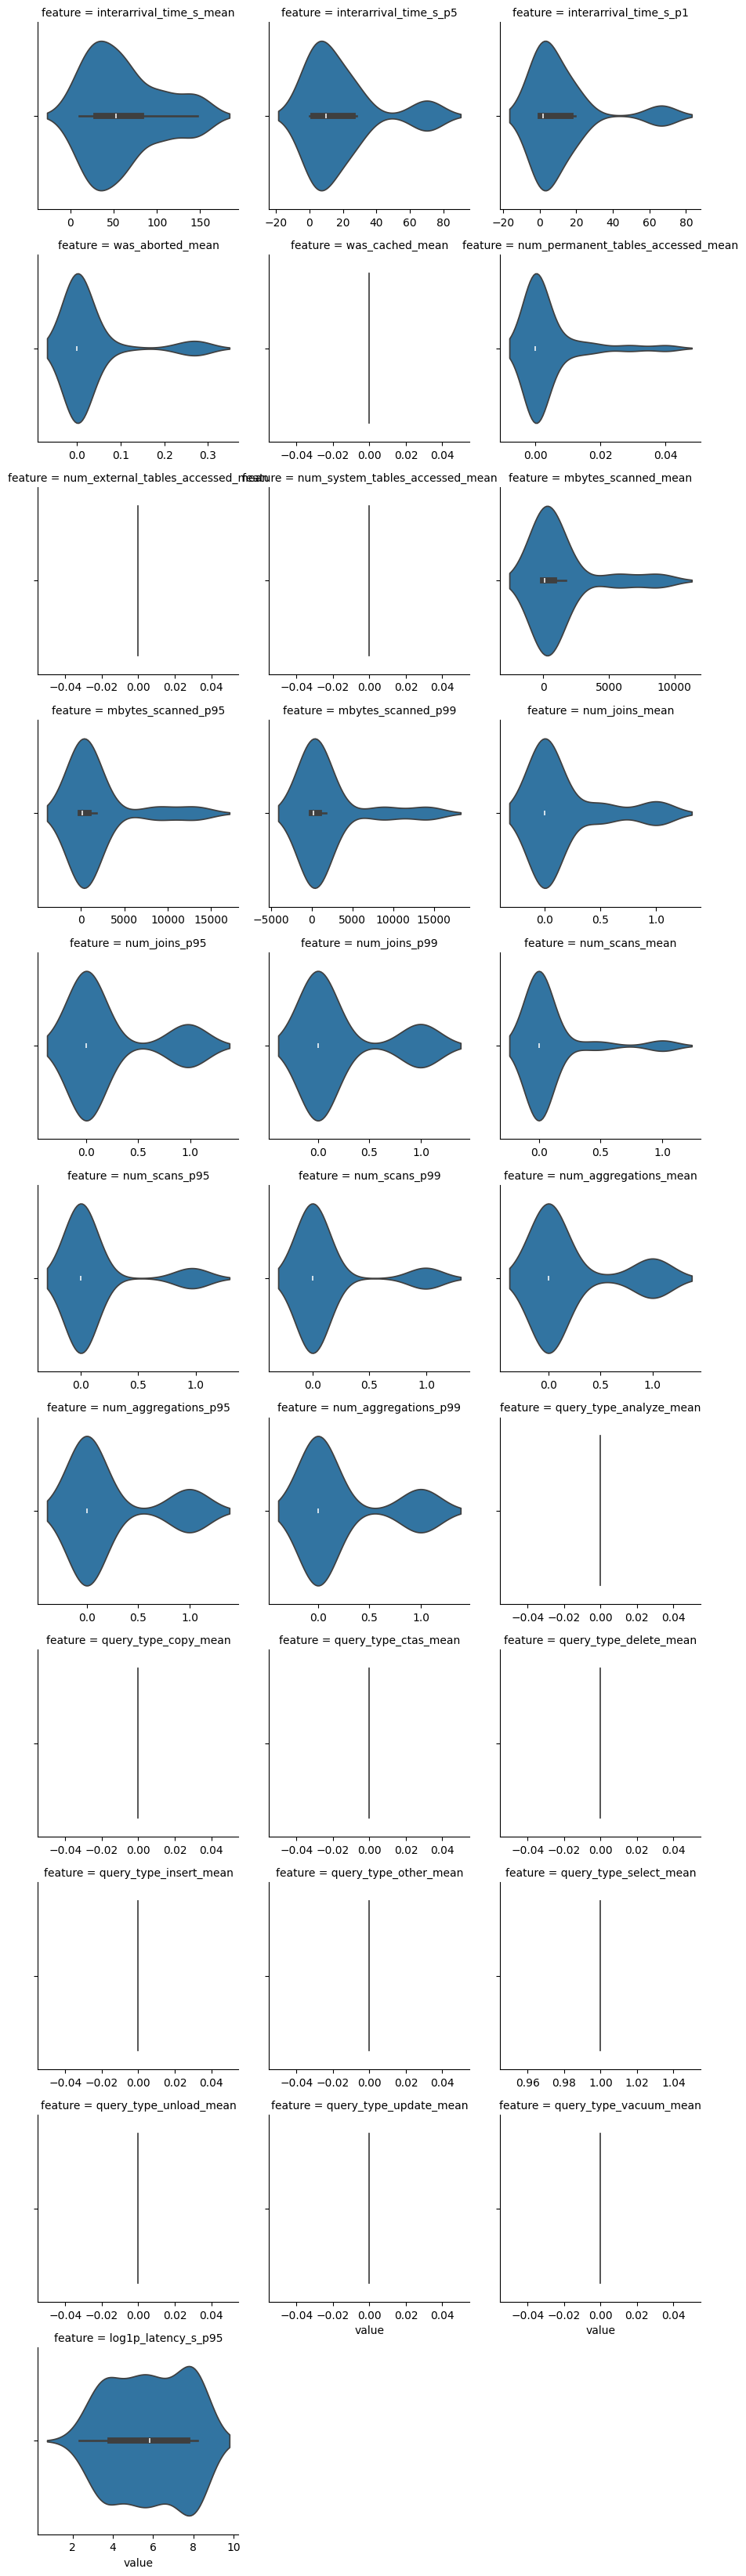

In [6]:
# Visualize the distribution of each feature and the label in a violin plot
# Each violin plot should be in its own subplot
import seaborn as sns
import matplotlib.pyplot as plt

melted_df = results_df.melt(
    id_vars=["pct_heavy", "mean_interarrival", "rpu"],
    value_vars=feature_names + [label_name],
    var_name="feature",
    value_name="value",
)
melted_df

g = sns.FacetGrid(melted_df, col="feature", col_wrap=3, sharex=False, sharey=False)
g.map(sns.violinplot, "value", order=None)
plt.show()